In [31]:
%matplotlib inline
import torch
from d2l import torch as d2l

In [32]:
class Data(d2l.DataModule):
    def __init__(
        self,
        batch_size=16,
        T=1000,
        num_train=600,
        tau=4,
    ):
        self.save_hyperparameters()
        
        # [1, 2, 3, ... 1000]
        self.time = torch.arange(
            1,
            T + 1,
            dtype=torch.float32
        )
        
        # sin([0.01, 0.02, ... 10]) + noise(0.2)
        self.x = (
            torch.sin(0.01 * self.time)
            + torch.randn(T) * 0.2
        )
        
        
    def get_dataloader(self, train):
        shifted_sequences = [
            #  [0:996]   [1:997]   [2:998]  [3:999]
            # x[0~995], x[1~996], x[2~997] x[3~998]
            self.x[i : self.T - self.tau + i]
            for i in range(self.tau) # 4
            # 0~995 / 1~996 / 2~997 / 3~998
        ]
        
        #  0   1   2   3  ->  4
        #  1   2   3   4  ->  5
        #         .           .
        #         .           .
        #         .           .
        # 995 996 997 998 -> 999
        self.features = torch.stack(
            shifted_sequences,
            dim=1,
        )
        self.labels = self.x[self.tau:].reshape((-1, 1))
        
        # train: [0: 600]
        # valid: [600:]
        indices = (
            slice(0, self.num_train) # [0 : 600]
            if train 
            else slice(self.num_train, None)
        )
        
        return self.get_tensorloader(
            [self.features, self.labels], 
            train,
            indices,
        )

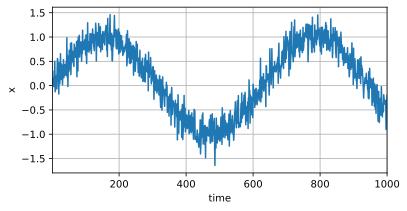

In [33]:
data = Data()

d2l.plot(
    data.time,
    data.x,
    "time",
    "x",
    xlim=[1, 1000],
    figsize=(6, 3),
)

In [34]:
train_dataloader = data.get_dataloader(train=True)
features, labels = next(iter(train_dataloader))

print("Full feature shape:", data.features.shape)
print("Full label shape:", data.labels.shape)
print("Batch feature shape:", features.shape)
print("Batch label shape:", labels.shape)

print("\nFirst feature:")
print(data.features[0])

print("\nFirst label:")
print(data.labels[0])

Full feature shape: torch.Size([996, 4])
Full label shape: torch.Size([996, 1])
Batch feature shape: torch.Size([16, 4])
Batch label shape: torch.Size([16, 1])

First feature:
tensor([0.0948, 0.1330, 0.0366, 0.1585])

First label:
tensor([-0.0200])


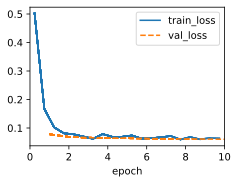

In [35]:
model = d2l.LinearRegression(lr=1e-2)
trainer = d2l.Trainer(max_epochs=10)

trainer.fit(
    model,
    data,
)